# Retail Sales Analysis and Sales Prediction

### Thiranex Data Science Internship - Task 4

**Author:** Obilipapannagari Sathwik Reddy

## Objective

The objective of this project is to analyze retail sales data, identify business insights, and build machine learning models to predict sales.

## Workflow

1. Import Libraries
2. Load Dataset
3. Dataset Overview
4. Data Understanding
5. Data Cleaning
6. Exploratory Data Analysis
7. Business Insights
8. Feature Engineering
9. Model Building
10. Model Evaluation
11. Conclusion

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

## 2. Load Dataset

In [2]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 3. Dataset Overview

In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 9994
Columns : 21


## 4. Data Understanding

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
df.describe(include="str")

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


In [8]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing.sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage
Row ID,0,0.0
Order ID,0,0.0
Order Date,0,0.0
Ship Date,0,0.0
Ship Mode,0,0.0
Customer ID,0,0.0
Customer Name,0,0.0
Segment,0,0.0
Country,0,0.0
City,0,0.0


In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

## 5. Data Cleaning

In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [12]:
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month_name()
df["Order Quarter"] = df["Order Date"].dt.quarter

In [13]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [14]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Quarter,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November,4,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November,4,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June,2,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October,4,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October,4,7


In [15]:
df.to_csv("../data/cleaned_superstore.csv", index=False)

## 6. Exploratory Data Analysis (EDA)

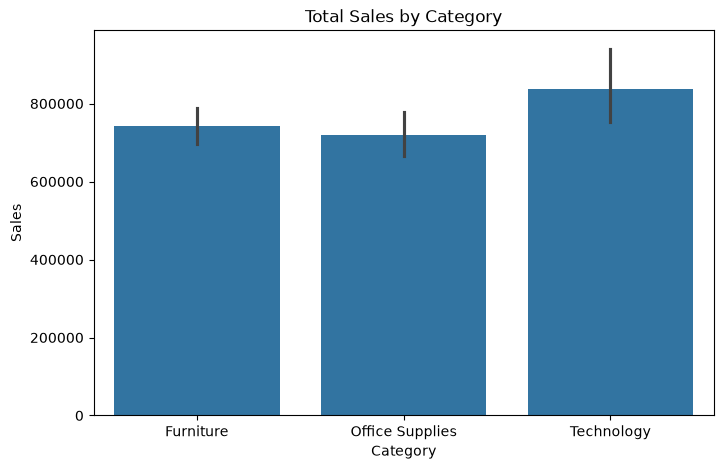

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Category",
    y="Sales",
    estimator="sum"
)

plt.title("Total Sales by Category")

plt.savefig("../images/sales_by_category.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

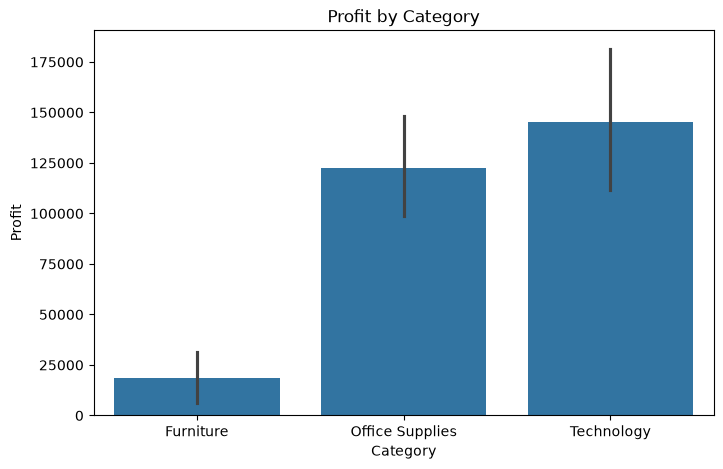

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Category",
    y="Profit",
    estimator="sum"
)

plt.title("Profit by Category")

plt.savefig("../images/profit_by_category.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

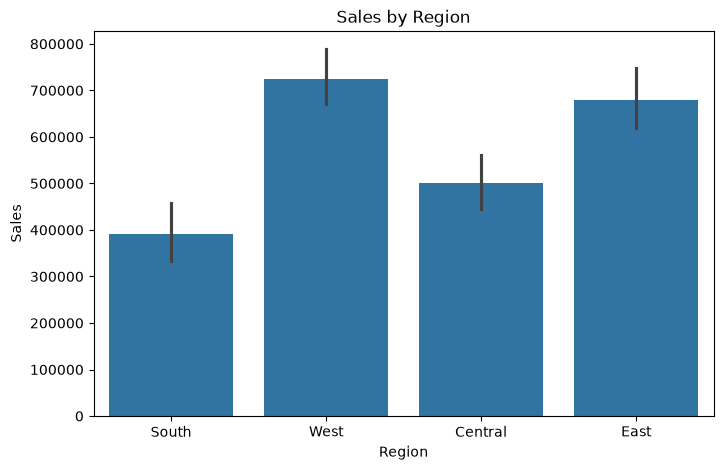

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Region",
    y="Sales",
    estimator="sum"
)

plt.title("Sales by Region")

plt.savefig("../images/sales_by_region.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

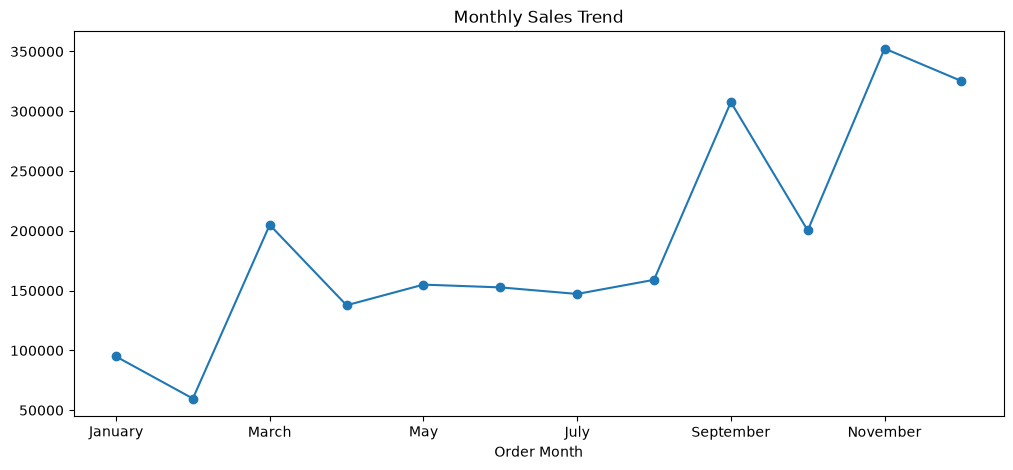

In [19]:
monthly_sales = (
    df.groupby("Order Month")["Sales"]
      .sum()
      .reindex([
          "January","February","March","April","May","June",
          "July","August","September","October","November","December"
      ])
)

plt.figure(figsize=(12,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")

plt.savefig("../images/monthly_sales_trend.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

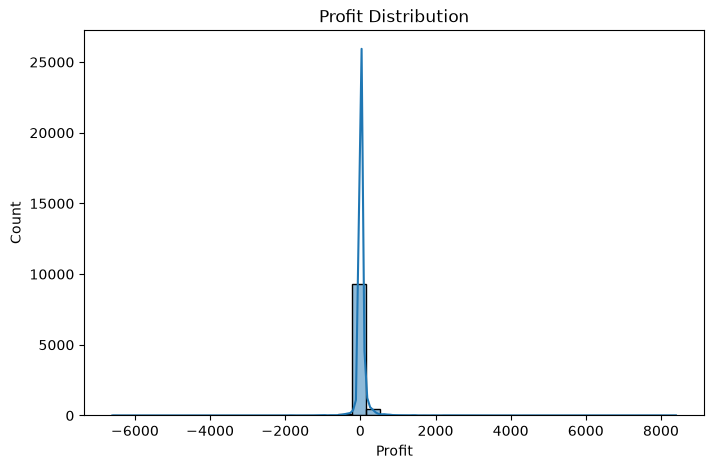

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df["Profit"], bins=40, kde=True)

plt.title("Profit Distribution")

plt.savefig("../images/profit_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

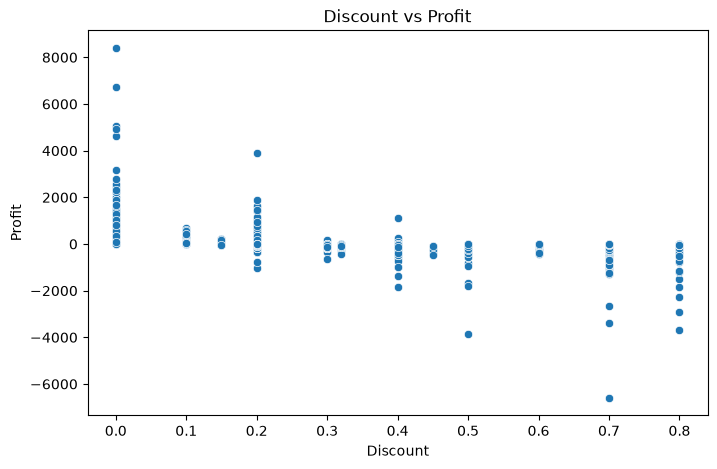

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit")

plt.savefig("../images/discount_vs_profit.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## 7. Feature Engineering & Data Preprocessing

In [22]:
X = df[[
    "Category",
    "Sub-Category",
    "Region",
    "Segment",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping Days"
]]

y = df["Sales"]

In [23]:
X = pd.get_dummies(X, drop_first=True)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
print(X_train.shape)
print(X_test.shape)

(7995, 27)
(1999, 27)


## 8. Model Building

In [26]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [27]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [28]:
rf = RandomForestRegressor(
    random_state=42,
    n_estimators=200
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## 9. Model Evaluation

In [29]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("-" * 30)
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score:", r2_score(y_true, y_pred))

In [30]:
evaluate_model("Linear Regression", y_test, lr_pred)

evaluate_model("Decision Tree", y_test, dt_pred)

evaluate_model("Random Forest", y_test, rf_pred)


Linear Regression
------------------------------
MAE : 199.13341969692968
RMSE: 753.5410985758339
R2 Score: 0.03872525475467081

Decision Tree
------------------------------
MAE : 106.13083981990995
RMSE: 610.659511313852
R2 Score: 0.36870565892336604

Random Forest
------------------------------
MAE : 82.35542953626808
RMSE: 487.79874523987434
R2 Score: 0.5971763109883022


In [31]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})

results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,R2 Score
2,Random Forest,0.597176
1,Decision Tree,0.368706
0,Linear Regression,0.038725


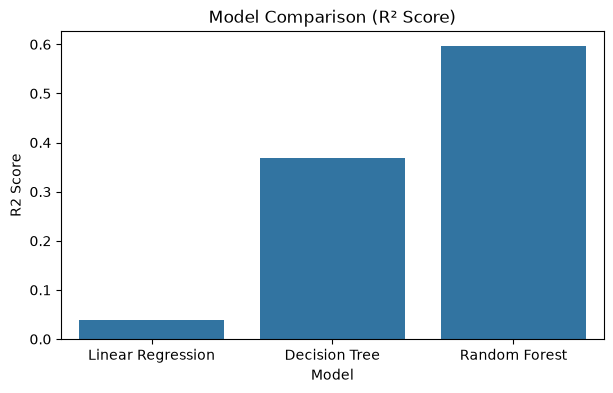

In [32]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison (R² Score)")

plt.savefig("../images/model_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Saving the model

In [33]:
import joblib

joblib.dump(rf, "../models/retail_sales_model.pkl")

['../models/retail_sales_model.pkl']

In [34]:
joblib.dump(X.columns.tolist(), "../models/feature_columns.pkl")

['../models/feature_columns.pkl']

## 10. Business Insights

### Key Findings

- Technology products generated the highest overall sales.
- Sales performance varied across different regions.
- Higher discounts were generally associated with lower profit.
- Monthly sales showed seasonal fluctuations.
- Random Forest achieved the best prediction performance with an R² score of **0.597**, outperforming Linear Regression and Decision Tree.
- Shipping time, product category, customer segment, and discounts all influenced sales.

## 11. Conclusion

This project analyzed a real-world retail sales dataset to understand sales patterns and build predictive models. Data preprocessing, feature engineering, exploratory data analysis, and regression modeling were performed.

Three regression models were evaluated:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Among them, **Random Forest** achieved the highest R² score and was selected as the best-performing model. The project demonstrates an end-to-end data science workflow, from data analysis to predictive modeling, and highlights how machine learning can support business decision-making.